In [6]:
import agrodesign
print(agrodesign)


<module 'agrodesign' from 'D:\\Git Projects\\AGRODESIGN\\agrodesign\\__init__.py'>


In [7]:
from agrodesign.analysis.anova import Anova
from agrodesign.mean_separation.lsd import LSD

In [8]:
import pandas as pd

df = pd.DataFrame({
    "Treatment": ["T1","T1","T2","T2","T3","T3"],
    "Yield": [10,12,15,14,18,17]
})

aov = Anova(df, response="Yield")
aov.crd(treatment="Treatment")


,DF,SS,MS,F,p-value
C(Treatment),2.0,42.333333,21.166667,21.166667,0.017024
Residual,3.0,3.000000,1.000000,NaN,NaN


In [9]:
aov.crd("Treatment")
aov.means("Treatment")
from agrodesign.mean_separation.dmrt import DMRT
DMRT(aov).test()

,Treatment,Mean,Replications,Group
0,T3,17.5,2,a
1,T2,14.5,2,a
2,T1,11.0,2,b


In [10]:
aov.means(treatment="Treatment")
lsd = LSD(aov)
lsd.test()

,Treatment,Mean,Replications,Group
0,T3,17.5,2,a
1,T2,14.5,2,a
2,T1,11.0,2,b


In [11]:
import pandas as pd
from agrodesign.analysis.anova import Anova
from agrodesign.mean_separation.lsd import LSD

df = pd.DataFrame({
    "Block": ["B1","B1","B1","B2","B2","B2"],
    "Treatment": ["T1","T2","T3","T1","T2","T3"],
    "Yield": [10,14,18,12,15,17]
})

aov = Anova(df, response="Yield")

# RCBD ANOVA
aov.rcbd(treatment="Treatment", block="Block")


,DF,SS,MS,F,p-value
C(Treatment),2.0,42.333333,21.166667,18.142857,0.052239
C(Block),1.0,0.666667,0.666667,0.571429,0.528595
Residual,2.0,2.333333,1.166667,NaN,NaN


In [12]:
# Treatment means
aov.means("Treatment")


,Treatment,Mean,Replications
0,T1,11.0,2
1,T2,14.5,2
2,T3,17.5,2


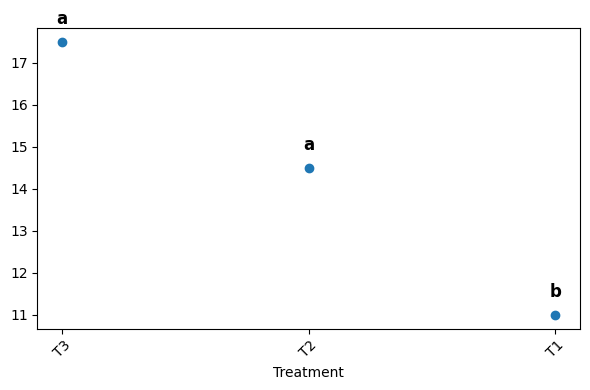

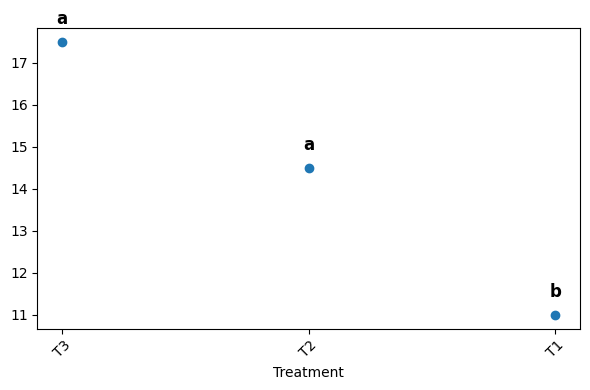

In [13]:
from agrodesign.plots.effect_plot import effect_plot
effect_plot(aov, "Treatment", method="dmrt")


In [14]:
# LSD test
lsd = LSD(aov)
lsd.test()


,Treatment,Mean,Replications,Group
0,T3,17.5,2,a
1,T2,14.5,2,a
2,T1,11.0,2,b


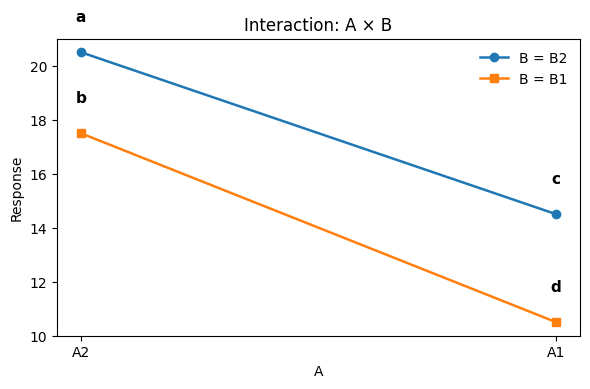

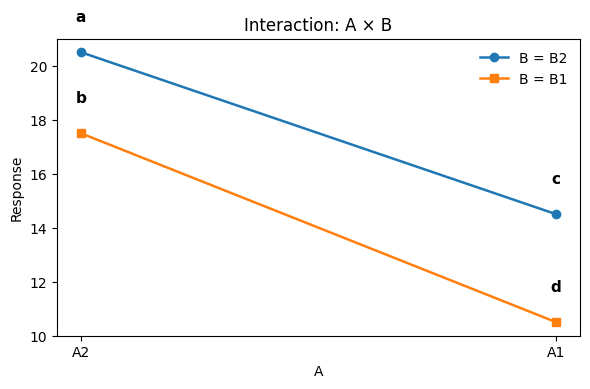

In [15]:
import pandas as pd
from agrodesign.analysis.anova import Anova
from agrodesign.plots.interaction_plot import interaction_plot

df = pd.DataFrame({
    "A": ["A1","A1","A1","A1","A2","A2","A2","A2"],
    "B": ["B1","B1","B2","B2","B1","B1","B2","B2"],
    "Yield": [10,11,14,15,18,17,20,21]
})

aov = Anova(df, response="Yield")

# factorial ANOVA
aov.factorial(["A","B"])
aov.factorial_means(["A","B"])

# interaction plot with letters
interaction_plot(aov, ["A","B"], method="dmrt")


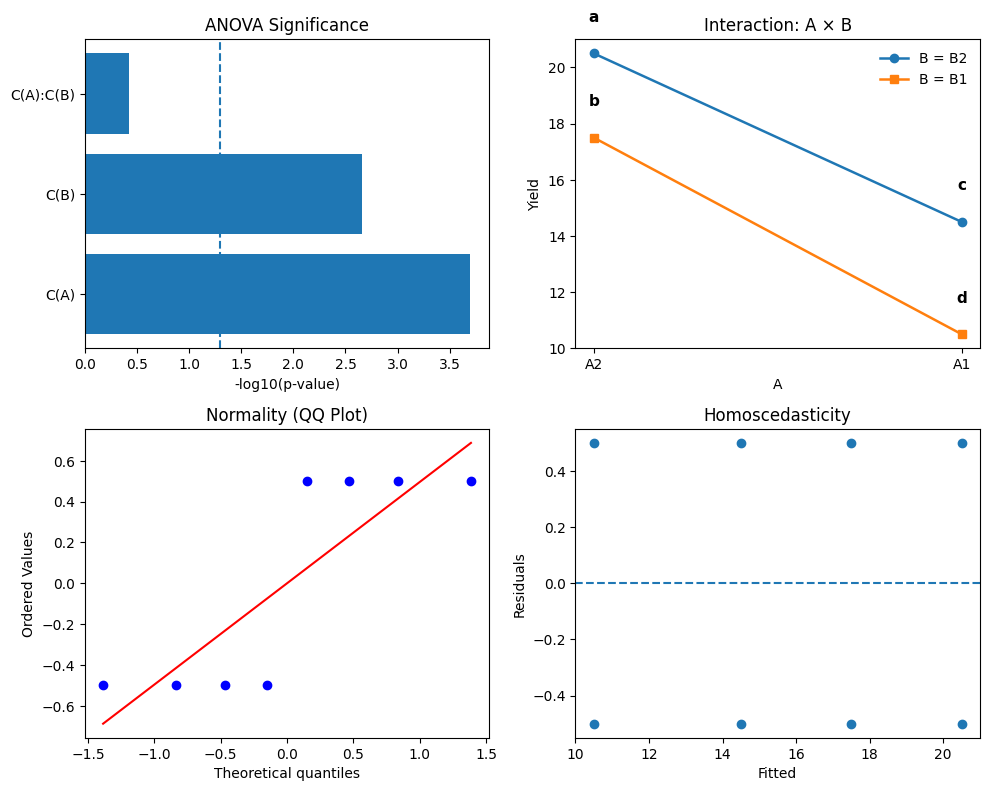

In [16]:
from agrodesign.plots.report_plot import report_plot
report_plot(aov, ["A","B"])


In [17]:
aov.factorial_means("A")

from agrodesign.mean_separation.lsd import LSD
lsd_A = LSD(aov)
lsd_A.test()


,A,Mean,Replications,Group
0,A2,19.0,4,a
1,A1,12.5,4,b


In [18]:
from agrodesign.analysis.assumptions import Assumptions

assump = Assumptions(aov)

# Normality
assump.shapiro_test()


{'Test': 'Shapiro-Wilk',
 'Statistic': np.float64(0.6646559035934576),
 'p-value': np.float64(0.0008917018985140214),
 'Normal': 'No'}

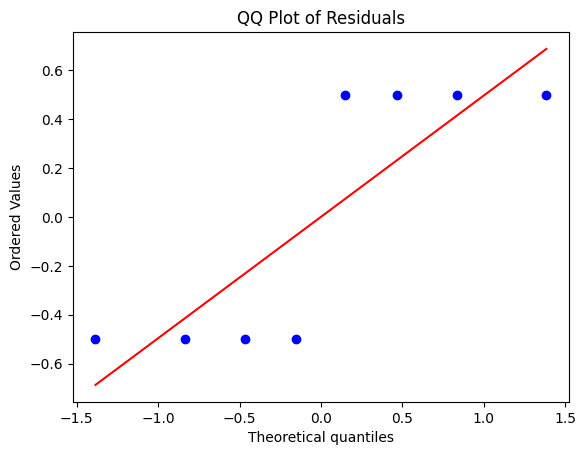

In [19]:
assump.qq_plot()


In [20]:
assump.bartlett_test("A")

{'Test': 'Bartlett',
 'Grouping': 'A',
 'Statistic': np.float64(0.8781123262779806),
 'p-value': np.float64(0.3487192197203338),
 'Homogeneous': 'Yes'}

In [21]:
df

,A,B,Yield
0,A1,B1,10
1,A1,B1,11
2,A1,B2,14
3,A1,B2,15
4,A2,B1,18
5,A2,B1,17
6,A2,B2,20
7,A2,B2,21


In [22]:
from agrodesign.mean_separation.tukey import TukeyHSD

tukey = TukeyHSD(aov,"A")
tukey.test()


,A,Mean,Replications,Group
0,A2,19.0,4,a
1,A1,12.5,4,b


In [23]:
from agrodesign.mean_separation.tukey import TukeyHSD

tukey_A = TukeyHSD(aov, ("A","B"))
tukey_A.test()


,A,Mean,Replications,Group
0,A2,19.0,4,a
1,A1,12.5,4,b


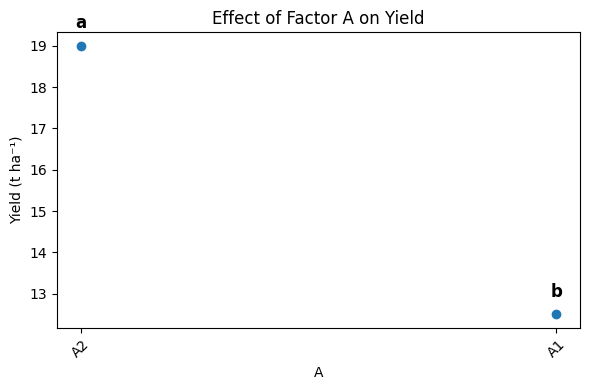

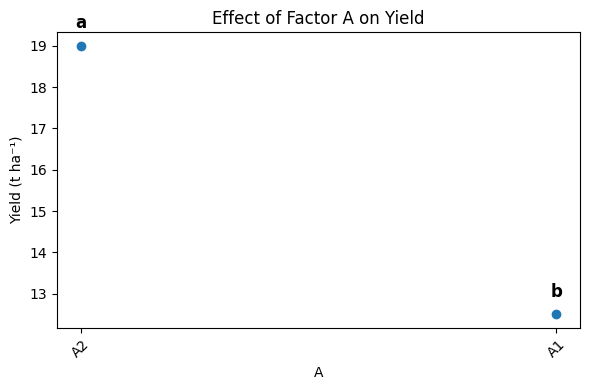

In [24]:
from agrodesign.mean_separation.tukey import TukeyHSD
from agrodesign.plots.mean_plot import mean_plot

tukey_A = TukeyHSD(aov, ("A","B"))
means_A = tukey_A.test()

mean_plot(
    means_df=means_A,
    factor="A:B",
    ylabel="Yield (t ha⁻¹)",
    title="Effect of Factor A on Yield",
    kind="point"
)


In [25]:
import pandas as pd
from agrodesign.analysis.anova import Anova
from agrodesign.mean_separation.lsd import LSD

In [26]:
import pandas as pd
from agrodesign.analysis.anova import Anova
from agrodesign.mean_separation.lsd import LSD
from agrodesign.mean_separation.tukey import TukeyHSD
df = pd.DataFrame({
    "Rep": [1]*8 + [2]*8 + [3]*8,
    "A": ["A1","A1","A1","A1","A2","A2","A2","A2"] * 3,
    "B": ["B1","B1","B2","B2","B1","B1","B2","B2"] * 3,
    "C": ["C1","C2","C1","C2","C1","C2","C1","C2"] * 3,
    "Yield": [
        10,12,11,13,15,17,16,18,
        11,13,12,14,16,18,17,19,
        12,14,13,15,17,19,18,20
    ]
})



In [27]:
aov = Anova(df, response="Yield")
anova_table = aov.split_plot(
    whole_plot="A",
    sub_plot="B",
    block="Rep",
    sub_sub_plot="C"
)

anova_table


,DF,SS,MS,F,p-value
C(Rep),2.0,1.600000e+01,8.000000e+00,3.597448e+27,1.528488e-108
C(A),1.0,1.500000e+02,1.500000e+02,1.188422e+31,0.000000e+00
C(B),1.0,6.000000e+00,6.000000e+00,1.301042e+30,0.000000e+00
C(C),1.0,2.400000e+01,2.400000e+01,1.079234e+28,8.255723e-110
C(Rep):C(A),2.0,2.524355e-29,1.262177e-29,5.675772e-03,9.943443e-01
C(A):C(B),1.0,2.174298e-29,2.174298e-29,4.714756e+00,9.566562e-02
C(A):C(C),1.0,1.972152e-29,1.972152e-29,8.868393e-03,9.272883e-01
C(B):C(C),1.0,3.081488e-33,3.081488e-33,1.385686e-06,9.990896e-01
C(Rep):C(A):C(B),4.0,1.844675e-29,4.611687e-30,2.073788e-03,9.999893e-01
C(A):C(B):C(C),1.0,4.039908e-29,4.039908e-29,1.816670e-02,8.961122e-01


In [28]:
aov.factorial_means(["A", "B", "C"])


,A,B,C,Mean,Replications
0,A1,B1,C1,11.0,3
1,A1,B1,C2,13.0,3
2,A1,B2,C1,12.0,3
3,A1,B2,C2,14.0,3
4,A2,B1,C1,16.0,3
5,A2,B1,C2,18.0,3
6,A2,B2,C1,17.0,3
7,A2,B2,C2,19.0,3


In [29]:
lsd_ABC = LSD(aov, effect="A:B:C")
lsd_ABC.test()

,A,B,C,Mean,Replications,Group
0,A2,B2,C2,19.0,3,a
1,A2,B1,C2,18.0,3,b
2,A2,B2,C1,17.0,3,c
3,A2,B1,C1,16.0,3,d
4,A1,B2,C2,14.0,3,e
5,A1,B1,C2,13.0,3,f
6,A1,B2,C1,12.0,3,g
7,A1,B1,C1,11.0,3,h


In [30]:
aov.factorial_means("A")

lsd_A = LSD(aov, effect="A")
lsd_A.test()

,A,Mean,Replications,Group
0,A2,17.5,12,a
1,A1,12.5,12,b


In [31]:
tukey_B = TukeyHSD(aov, effect="B")
tukey_B.test()


,A,Mean,Replications,Group
0,A2,17.5,12,a
1,A1,12.5,12,b


In [32]:
aov.factorial_means(["A","C"])
LSD(aov, effect="A:C").test()

aov.factorial_means(["B","C"])
TukeyHSD(aov, effect="B:C").test()


,B,C,Mean,Replications,Group
0,B2,C2,16.5,6,a
1,B1,C2,15.5,6,b
2,B2,C1,14.5,6,c
3,B1,C1,13.5,6,d


In [33]:
import pandas as pd
from agrodesign.analysis.anova import Anova
from agrodesign.plots.boxplot_letters import boxplot_letters


In [34]:
import pandas as pd

df = pd.DataFrame({
    "Rep": [1]*8 + [2]*8 + [3]*8,
    "A": ["A1","A1","A1","A1","A2","A2","A2","A2"] * 3,
    "B": ["B1","B1","B2","B2","B1","B1","B2","B2"] * 3,
    "C": ["C1","C2","C1","C2","C1","C2","C1","C2"] * 3,
    "Yield": [
        10,12,11,13,15,17,16,18,
        11,13,12,14,16,18,17,19,
        12,14,13,15,17,19,18,20
    ]
})

In [35]:
from agrodesign.experiment import Experiment
import matplotlib.pyplot as plt  # Ensure matplotlib is imported for displaying plots

# Assuming df is your DataFrame with the data
result = Experiment(df, "Yield").factorial(["A", "B", "C"]).run()

In [36]:
result

AgroResult (Factorial Experiment)
Response: Yield
Significant factors: A, B, C
Best treatment: A2 × B2 × C2
Expected yield: 19.00

In [37]:
Experiment(df, "Yield").factorial(["A", "B", "C"]).run()

AGRODESIGN ANALYSIS

FACTORIAL EXPERIMENT ANALYSIS
Response variable: Yield
Post-hoc test: Tukey HSD (α = 0.05)

--------------------------------------------------
ANOVA TABLE
--------------------------------------------------
Source            DF            MS             F p-value Significance
C(A)             1.0  1.500000e+02  1.500000e+02  <0.001          ***
C(B)             1.0  6.000000e+00  6.000000e+00   0.026            *
C(C)             1.0  2.400000e+01  2.400000e+01  <0.001          ***
C(A):C(B)        1.0  1.953435e-28  1.953435e-28   1.000           ns
C(A):C(C)        1.0  1.449532e-29  1.449532e-29   1.000           ns
C(B):C(C)        1.0  8.549280e-29  8.549280e-29   1.000           ns
C(A):C(B):C(C)   1.0  2.662406e-30  2.662406e-30   1.000           ns
Residual        16.0  1.000000e+00           NaN     nan           ns

Highest significant effect: A

Interpretation rule:
No interaction detected → interpret main effects

----------------------------------------

AgroResult (Factorial Experiment)
Response: Yield
Significant factors: A, B, C
Best treatment: A2 × B2 × C2
Expected yield: 19.00

In [38]:
result.summary()


================ AGRONOMIC INTERPRETATION ================

FACTORIAL INTERPRETATION

Interpretation restricted to C(A) due to significant effect.
Significant factors : A, B, C.
No interaction detected. Factors act independently.
Best levels:
A2, B2, C2.
Best combination    : A2 × B2 × C2
Expected mean       : 19.00
Recommendation      : Adopt A2 × B2 × C2 for maximizing yield



In [13]:
result.export('report')

In [39]:
import pandas as pd
from agrodesign.experiment import Experiment

df = pd.DataFrame({
    "Treatment": ["T1","T2","T3","T4"] * 5,
    "Yield": [
        42,50,55,60,
        41,48,53,59,
        43,49,56,61,
        40,47,54,58,
        44,51,57,62
    ]
})


In [41]:
Experiment(df,"Yield").crd("Treatment").run()


AGRODESIGN ANALYSIS

CRD ANALYSIS
Response variable: Yield
Post-hoc test: Tukey HSD (α = 0.05)

--------------------------------------------------
ANOVA TABLE
--------------------------------------------------
Source          DF          MS           F p-value Significance
C(Treatment)   3.0  301.666667  120.666667  <0.001          ***
Residual      16.0    2.500000         NaN     nan           ns

Highest significant effect: Treatment

Interpretation rule:
No interaction detected → interpret main effects

--------------------------------------------------
POST HOC TEST CRITICAL VALUES
--------------------------------------------------
HSD(Treatment) = 2.8612

--------------------------------------------------
MEAN COMPARISON (ALL EFFECTS)
--------------------------------------------------

MAIN EFFECTS
---------------

Factor Treatment
  Mean Group
60.000     a
55.000     b
49.000     c
42.000     d

--------------------------------------------------
AGRONOMIC INTERPRETATION
--------

AgroResult (CRD)
Response: Yield
Significant factors: Treatment
Best treatment: 0
Expected yield: 60.00

In [42]:
df = pd.DataFrame({
    "Block": [1,1,1,1,2,2,2,2,3,3,3,3],
    "Variety": ["V1","V2","V3","V4"]*3,
    "Yield": [
        45,50,55,60,
        44,49,54,59,
        46,51,56,61
    ]
})
Experiment(df,"Yield").rcbd("Variety","Block").run()


AGRODESIGN ANALYSIS

RCBD ANALYSIS
Response variable: Yield
Post-hoc test: Tukey HSD (α = 0.05)

--------------------------------------------------
ANOVA TABLE
--------------------------------------------------
Source       DF            MS             F p-value Significance
C(Variety)  3.0  1.250000e+02  2.971056e+29  <0.001          ***
C(Block)    2.0  4.000000e+00  9.507380e+27  <0.001          ***
Residual    6.0  4.207258e-28           NaN     nan           ns

Highest significant effect: Variety

Interpretation rule:
No interaction detected → interpret main effects

--------------------------------------------------
POST HOC TEST CRITICAL VALUES
--------------------------------------------------
HSD(Variety) = 0.0000

--------------------------------------------------
MEAN COMPARISON (ALL EFFECTS)
--------------------------------------------------

MAIN EFFECTS
---------------

Factor Variety
  Mean Group
60.000     a
55.000     b
50.000     c
45.000     d

---------------------

AgroResult (RCBD)
Response: Yield
Significant factors: Variety, Block
Best treatment: 0
Expected yield: 60.00

In [43]:
df = pd.DataFrame({
    "Rep":[1]*8+[2]*8+[3]*8,
    "Irrigation":["I1","I1","I1","I1","I2","I2","I2","I2"]*3,
    "Variety":["V1","V2","V1","V2","V1","V2","V1","V2"]*3,
    "Yield":[
        20,22,21,23,25,27,26,28,
        21,23,22,24,26,28,27,29,
        22,24,23,25,27,29,28,30
    ]
})

result = Experiment(df,"Yield").split_plot("Irrigation","Variety","Rep").run()
print(result)
result.summary()

AGRODESIGN ANALYSIS

SPLIT ANALYSIS
Response variable: Yield
Post-hoc test: Tukey HSD (α = 0.05)

--------------------------------------------------
ANOVA TABLE
--------------------------------------------------
Source                      DF            MS             F p-value Significance
C(Rep)                     2.0  8.000000e+00  2.133333e+01  <0.001          ***
C(Irrigation)              1.0  1.500000e+02  2.376845e+31  <0.001          ***
C(Variety)                 1.0  2.400000e+01  6.400000e+01  <0.001          ***
C(Rep):C(Irrigation)       2.0  6.310887e-30  1.682903e-29   1.000           ns
C(Irrigation):C(Variety)   1.0  2.839899e-29  7.573065e-29   1.000           ns
Residual                  16.0  3.750000e-01           NaN     nan           ns

Highest significant effect: Rep

Interpretation rule:
No interaction detected → interpret main effects

--------------------------------------------------
POST HOC TEST CRITICAL VALUES
------------------------------------------

In [44]:
import pandas as pd
from agrodesign.experiment import Experiment

df = pd.DataFrame({
    "Block":[1,1,1,2,2,2,3,3,3],
    "Treatment":["T1","T2","T3"]*3,
    "Yield":[42,50,55,40,48,54,43,49,56]
})
result = Experiment(df,"Yield").mixed(fixed=["Treatment"], random=["Block"]).run()

In [45]:
result

AgroResult (MIXED MODEL)
Response: Yield
Best level: T3
BLUP: 55.00

In [49]:
print(result)

AGRODESIGN ANALYSIS

MIXED MODEL ANALYSIS
Response variable: Yield
Post-hoc test: Tukey HSD (α = 0.05)

Variance components:
--------------------------------
Block (random)     1.00
Residual (random)     0.44

BLUPs (Treatment effects)
--------------------------------
T3    55.0
T2    49.0
T1    41.7

Normality test (Shapiro-Wilk): p = 0.54
Residuals: Normally distributed

--------------------------------------------------
FINAL RECOMMENDATION
--------------------------------------------------
After adjusting for block-to-block variability,
treatment T3 consistently produced superior yield.

Farmers should adopt treatment T3 across environments.

Expected improvement: +32% compared to T1



In [1]:
import pandas as pd
from agrodesign.experiment import Experiment
df = pd.DataFrame({
    "Genotype":["G1","G2","G3","G4"]*8,
    "Environment":(["E1"]*4 + ["E2"]*4 + ["E3"]*4 + ["E4"]*4)*2,
    "Rep":[1]*16 + [2]*16,
    "Yield":[
        45,50,55,60,
        40,48,53,58,
        47,52,57,62,
        43,49,54,59,

        46,51,56,61,
        41,47,52,57,
        48,53,58,63,
        44,50,55,60
    ]
})
result = Experiment(df,"Yield").gxe("Genotype","Environment","Rep").run()


In [2]:
print(result)

AGRODESIGN ANALYSIS

GxE ANALYSIS
Response variable: Yield
Post-hoc test: Tukey HSD (α = 0.05)

--------------------------------------------------
ANOVA TABLE
--------------------------------------------------
Source                        DF          MS           F p-value Significance
C(Genotype)                  3.0  364.458333  728.916667  <0.001          ***
C(Environment)               3.0   42.458333   84.916667  <0.001          ***
C(Genotype):C(Environment)   9.0    0.458333    0.916667   0.535           ns
Residual                    16.0    0.500000         NaN     nan           ns

Highest significant effect: Genotype

Interpretation rule:
No interaction detected → interpret main effects

Heritability (broad sense): 0.99

Genotype BLUPs
---------------
G4   7.7
G3   2.7
G2   -2.3
G1   -8.1

Stability (AMMI/IPCA1)
----------------------
Most stable genotype: G2

Mega-environment winner
-----------------------
E1 → G4
E2 → G4
E3 → G4
E4 → G4

FINAL RECOMMENDATION
------------

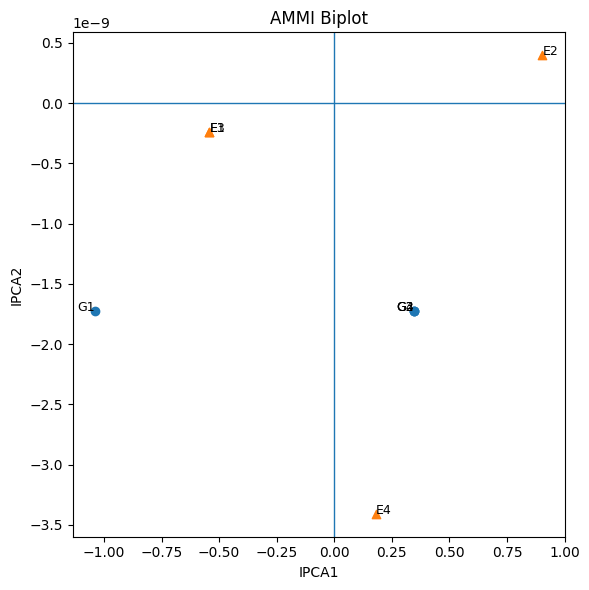

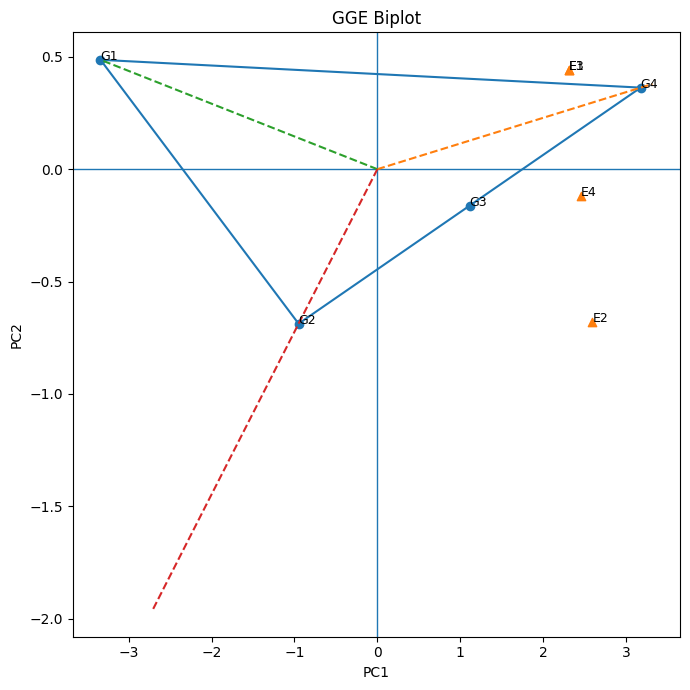

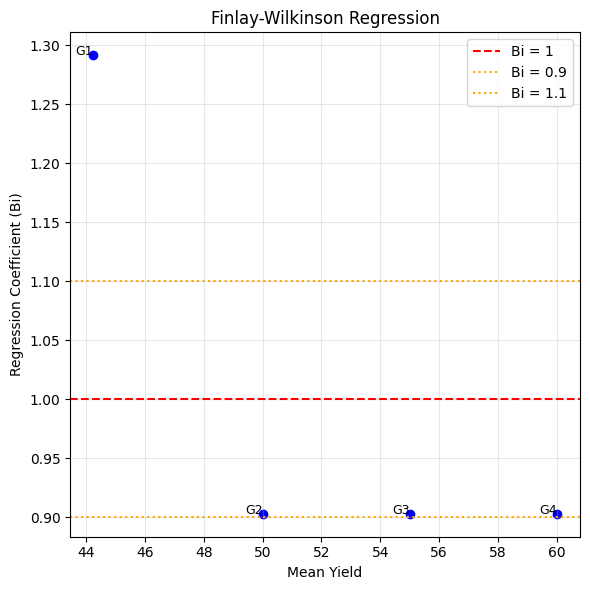

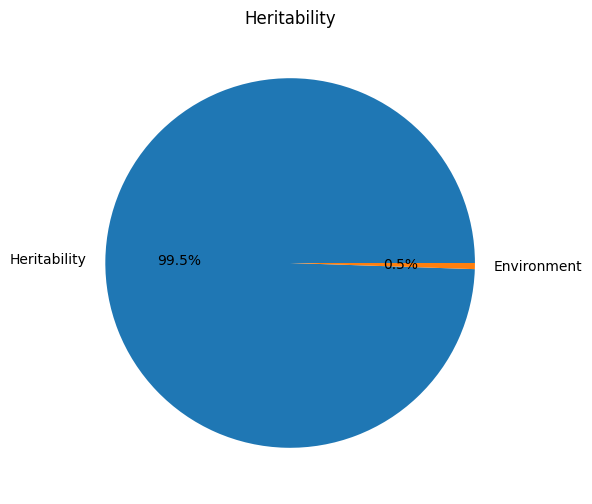

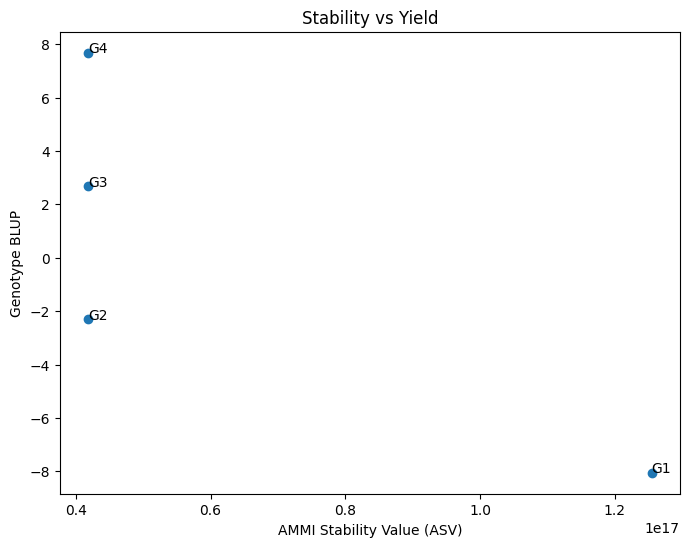

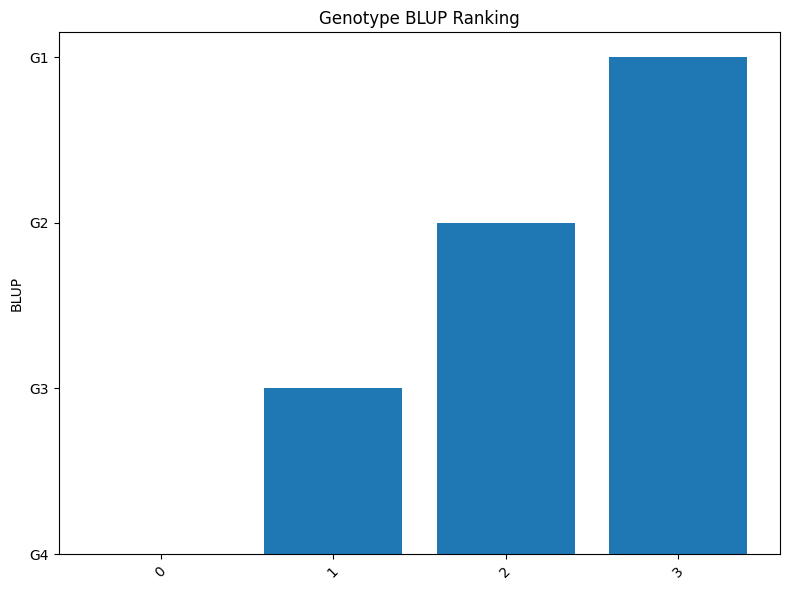

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [3]:
result.plot()

In [1]:
import pandas as pd